In [1]:
# Google Colab only: clone the repository and install its pinned requirements.
# Run locally (from the repository root or notebooks/), this cell does nothing.
import os, subprocess, sys

if "google.colab" in sys.modules:
    repo = "/content/BlueBan-813"
    if not os.path.isdir(repo):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/4waiz/BlueBan-813", repo], check=True)
    os.chdir(repo)
    # Colab runs its own Jupyter server and kernel: keep those, install everything else as pinned.
    colab_own = ("jupyterlab", "ipykernel", "nbclient", "nbconvert", "nbformat", "argon2-cffi-bindings")
    reqs = [r.split("#")[0].strip() for r in open("requirements.txt", encoding="utf-8")]
    reqs = [r for r in reqs if r and not r.lower().startswith(colab_own)]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *reqs], check=True)
    print("Colab: repository and requirements ready. If numpy or pandas changed version, use "
          "Runtime > Restart session and run all cells again.")

# BLUEBAN 813: a coastal water-quality incident, reproduced from the sample input

**Team Kanban** · Arab Youth Space Hackathon 2026 · 813 Challenge · Theme: *Water Quality & Inland/Coastal Water Intelligence*

BLUEBAN 813 watches UAE coastal water with Sentinel-2 L2A and treats every unusual water colour as an
**incident** that moves through a governed loop: WATCH → DETECT → DIAGNOSE → VERIFY → ACT → LEARN.
The key idea is *temporal*, not spatial: every 20 m water pixel is compared with **its own history at the
same time of year in other years**, so permanent features (bright sand, seagrass, dredged channels) sit in
the middle of their own distribution and only genuinely new events stand out. This notebook reproduces,
offline and on a laptop CPU, the evidence behind the hero incident **BB-AE-2024-001** (Fujairah, 17 February
2024, 06:49 UTC): a **bloom-like optical anomaly**, currently *under review*. It then shows what a
hyperspectral Satellite 813 band set adds (on **simulated** 813 bands) and how the learning loop decides
whether a retrained model may replace the production rule.

**What you will see**

1. Setup: versions, seeds, paths and a check of the sample input.
2. The Sentinel-2 L2A event image: digital numbers → reflectance with the baseline-aware offset, scene
   classification and the water mask, true colour.
3. Water-quality features (NDCI, MCI, hue angle, turbidity), all labelled for what they are (PROXY indices).
4. **DETECT**: per-pixel robust z-score and seasonal percentile against the pixel's own same-season history,
   the event polygon (z ≥ 3, ≥ 95th percentile), its area, and a comparison with the committed incident.
5. **DIAGNOSE**: event vs background spectrum, colour change, and the same-morning Sentinel-3 OLCI cross-check
   (loaded from the committed pipeline output).
6. **Satellite 813 (simulated)**: real Tanager-1 hyperspectral spectra convolved to Sentinel-2 and to the
   813 band set, and the measured ablation.
7. **LEARN**: production rule vs a retrained candidate on a frozen validation split, the promotion gate, and why
   it stops at a named human.
8. Results written to `results/`, and 9. a table of computed vs published numbers with limitations.

**Runtime**: well under a minute on a laptop (no GPU, no network). Inputs: `data/sample_input/` (Sentinel-2
clip and seasonal baseline, regenerated by `scripts/fetch_sample_input.py`) and committed files in `outputs/`.

> **Reading rules used throughout.** "Bloom-like optical anomaly", never "harmful algal bloom confirmed": no
> species, toxin or concentration is claimed without a water sample. Spectral indices are **PROXY** values,
> never concentrations. Sentinel-3 OLCI is a **cross-sensor reference** (a model product), never ground truth.
> **Satellite 813 is SIMULATED**: no 813 product is available to teams.

## 1. Setup

Paths are resolved from the notebook's location (repository root or `notebooks/`), the repository root is put
on `sys.path` so `import pipeline` works after `pip install -r requirements.txt` (no editable install), and every
random number generator is seeded. Library warnings are silenced so that no output carries a local install path.

In [2]:
import json, os, platform, random, sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")          # library warnings print local install paths; nothing below relies on them
T0 = time.time()

import numpy as np
np.seterr(all="ignore")                    # NaN-aware maths over land/cloud pixels is intended
SEED = 813
random.seed(SEED)
np.random.seed(SEED)


def find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "pipeline" / "s2_features.py").is_file() and (p / "pyproject.toml").is_file():
            return p
    raise FileNotFoundError("Start the notebook inside the BlueBan-813 repository (root or notebooks/).")


ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(ROOT)                             # from here on every path is relative to the repository root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
import scipy
import shapely
import sklearn
from scipy import ndimage as ndi

from pipeline import detect, export, learning
from pipeline import s2_features as s2f
from pipeline import satellite813 as s813

%matplotlib inline
plt.rcParams.update({"figure.dpi": 80, "savefig.dpi": 110, "font.size": 9,
                     "axes.titlesize": 10, "figure.facecolor": "white"})
pd.set_option("display.precision", 4)

SAMPLE = Path("data/sample_input")
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

manifest_path = SAMPLE / "manifest.json"
if not manifest_path.exists():
    raise FileNotFoundError("data/sample_input/ is missing. From the repository root run:\n"
                            "    python scripts/fetch_sample_input.py\n"
                            "(anonymous Planetary Computer access, no credentials).")
MANIFEST = json.loads(manifest_path.read_text(encoding="utf-8"))
needed = [MANIFEST["event"]["file"], MANIFEST["baseline"]["file"], MANIFEST["baseline"]["transect_file"]]
missing = [f for f in needed if not (SAMPLE / f).exists()]
if missing:
    raise FileNotFoundError(f"missing in data/sample_input/: {missing}; run python scripts/fetch_sample_input.py")

print(f"Python {platform.python_version()} on {platform.system()}")
for name, mod in [("numpy", np), ("scipy", scipy), ("scikit-learn", sklearn), ("pandas", pd),
                  ("matplotlib", matplotlib), ("shapely", shapely), ("rasterio", rasterio)]:
    print(f"  {name:13s}{mod.__version__}")
print(f"  {'GDAL':13s}{rasterio.__gdal_version__}")
print(f"\nSeeds: random / numpy = {SEED}. Repository root: '.' (relative paths only).")
print("\nSample input (data/sample_input/):")
for f in sorted(SAMPLE.iterdir()):
    print(f"  {f.name:42s}{f.stat().st_size / 1e6:6.2f} MB")

Python 3.11.9 on Windows
  numpy        2.4.6
  scipy        1.17.1
  scikit-learn 1.9.1
  pandas       3.0.6
  matplotlib   3.11.2
  shapely      2.1.2
  rasterio     1.4.4
  GDAL         3.10.3

Seeds: random / numpy = 813. Repository root: '.' (relative paths only).

Sample input (data/sample_input/):
  manifest.json                               0.02 MB
  README.md                                   0.00 MB
  s2l2a_20240217_fujairah_20m_dn.tif          3.29 MB
  seasonal_baseline_20m.tif                   5.15 MB
  seasonal_baseline_transect.npz              0.24 MB


## 2. The Sentinel-2 L2A event image

The clip is a 12.0 × 11.2 km window of the incident's own 20 m analysis grid (UTM zone 40N, same pixels and
alignment as `outputs/incidents/BB-AE-2024-001.json`), read from Planetary Computer with the pipeline's reader
(`pipeline.watch.load_datatake`) and stored as **digital numbers (DN)**. Since processing baseline 04.00, ESA
adds `BOA_ADD_OFFSET = -1000` to every L2A band, so reflectance is `(DN - 1000) / 10000`. The switch depends on
the **product's own processing baseline**, not on the acquisition date (older scenes have been reprocessed),
which is why the baseline is stored with the file and decoded by `s2_features.dn_to_reflectance`. The 20 m and
60 m bands are the original integer DN; the reader averages the 10 m bands onto the 20 m grid, so B04 is kept
at full float precision (bit-identical to the pipeline) and B02/B03 are rounded to the nearest DN.

The water mask (`s2_features.water_quality_mask`) keeps pixels that are valid, not cloud or cloud shadow in
the Scene Classification Layer (SCL), have MNDWI > 0 and B11 < 0.10 (rejects land, cloud, whitecaps and
strong glint), lie at least 60 m from non-water, and keep a non-negative red reflectance after the SWIR
offset correction.

In [3]:
EVENT_TIF = SAMPLE / MANIFEST["event"]["file"]
with rasterio.open(EVENT_TIF) as src:
    NAMES = list(src.descriptions)
    DN = {nm: src.read(i + 1) for i, nm in enumerate(NAMES)}
    TAGS = src.tags()
    GT, CRS, H, W = src.transform, src.crs, src.height, src.width
BANDS = [b for b in NAMES if b != "SCL"]
BASELINE, PLATFORM = TAGS["PROCESSING_BASELINE"], TAGS["PLATFORM"]
EPSG = CRS.to_epsg()
RES = GT.a
PX_KM2 = RES * RES / 1e6

refl = {b: s2f.dn_to_reflectance(DN[b], BASELINE) for b in BANDS}
scl = DN["SCL"].astype("uint8")

print(f"STAC item        {TAGS['STAC_ITEMS']}")
print(f"Acquired         {TAGS['DATETIME_UTC']}  ({PLATFORM})")
print(f"Processing base. {BASELINE}  ->  BOA_ADD_OFFSET = {s2f.boa_offset_for_baseline(BASELINE):+.0f} DN, "
      f"quantification {s2f.S2_QUANTIFICATION:.0f}")
print(f"Grid             EPSG:{EPSG}, {H} x {W} px at {RES:.0f} m = {H * RES / 1000:.1f} x {W * RES / 1000:.1f} km")
print(f"Bands            {', '.join(BANDS)} + SCL")
water, qrep = s2f.water_quality_mask(refl, scl, pixel_size_m=RES, shoreline_buffer_m=60.0, hole_buffer=False)
valid = np.isfinite(refl["B03"])
# the whole water body (as scripts/build_incidents.py): used for display and for distance to the coast
body = (valid & np.isfinite(refl["B11"]) & (refl["B11"] < 0.10) & ((refl["B03"] - refl["B11"]) > 0))
q = qrep.to_dict()
r0, c0 = (int(v) for v in np.argwhere(water)[q["water_px"] // 2])     # an analysable water pixel
off = s2f.boa_offset_for_baseline(BASELINE)
print(f"Example pixel (row {r0}, col {c0}): B05 DN {DN['B05'][r0, c0]:.0f} -> ({DN['B05'][r0, c0]:.0f} - {-off:.0f}) / 10000 "
      f"= {refl['B05'][r0, c0]:.4f}; B04 DN {DN['B04'][r0, c0]:.3f} (10 m average) -> {refl['B04'][r0, c0]:.5f}")
print(f"\nAnalysable water {q['water_px']:,} px ({q['water_px'] * PX_KM2:.0f} km2, {q['water_fraction']:.0%} of the clip); "
      f"glint-flagged {q['glint_or_float_px']:,} px; negative corrected red {q['negative_red_px']:,} px; "
      f"SCL-unusable {q['scl_unusable_px']:,} px")
vals, cnts = np.unique(scl, return_counts=True)
print("SCL classes in the clip: " + ", ".join(f"{s2f.SCL_CLASSES[int(v)]} {c / scl.size:.1%}"
                                          for v, c in sorted(zip(vals, cnts), key=lambda t: -t[1]) if c / scl.size >= 0.001))

STAC item        S2A_MSIL2A_20240217T064941_R020_T40RDN_20240217T105525


Acquired         2024-02-17T06:49:41.024000Z  (Sentinel-2A)
Processing base. 05.10  ->  BOA_ADD_OFFSET = -1000 DN, quantification 10000
Grid             EPSG:32640, 600 x 560 px at 20 m = 12.0 x 11.2 km
Bands            B01, B02, B03, B04, B05, B06, B8A, B11, B12 + SCL
Example pixel (row 294, col 469): B05 DN 1160 -> (1160 - 1000) / 10000 = 0.0160; B04 DN 1083.478 (10 m average) -> 0.00835

Analysable water 295,080 px (118 km2, 88% of the clip); glint-flagged 3 px; negative corrected red 26,693 px; SCL-unusable 307 px
SCL classes in the clip: water 99.0%, not_vegetated 0.9%


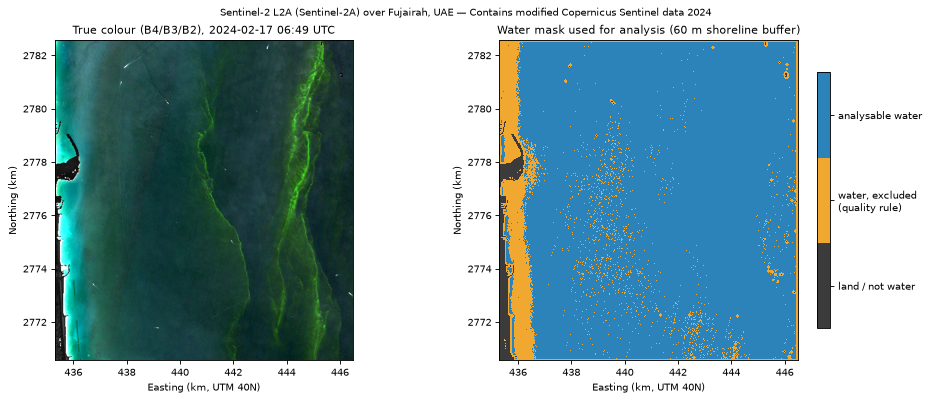

In [4]:
EXTENT = [GT.c / 1000, (GT.c + W * RES) / 1000, (GT.f - H * RES) / 1000, GT.f / 1000]   # UTM km


def true_colour(refl, valid, water_disp, land_gain=0.30, land_sat=0.18):
    """Display RGB with the same stretch as pipeline.export.save_rgb_png: one shared stretch on the WATER
    percentiles (1-99.2 %, gamma 0.78) so water colour is readable, land darkened and desaturated."""
    stack = np.dstack([refl["B04"], refl["B03"], refl["B02"]])
    v = stack[water_disp]
    v = v[np.isfinite(v)]
    lo, hi = np.percentile(v, [1.0, 99.2])
    rgb = np.nan_to_num(np.power(np.clip((stack - lo) / (hi - lo), 0, 1), 0.78))
    land = valid & ~water_disp
    lrgb = np.nan_to_num(np.dstack([export.stretch(refl[b], land, 2, 98)[0] for b in ("B04", "B03", "B02")]))
    lum = lrgb.mean(axis=2, keepdims=True)
    rgb = np.where(land[..., None], (lum + (lrgb - lum) * land_sat) * land_gain, rgb)
    rgb[~valid] = 1.0
    return rgb


def km_axes(ax):
    ax.set_xlabel("Easting (km, UTM 40N)")
    ax.set_ylabel("Northing (km)")


RGB = true_colour(refl, valid, body | water)
cls = np.full((H, W), 0, np.uint8)              # 0 land / no water
cls[body & ~water] = 1                          # water excluded by a quality rule
cls[water] = 2                                  # analysable water
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.9), constrained_layout=True)
ax[0].imshow(RGB, extent=EXTENT)
ax[0].set_title(f"True colour (B4/B3/B2), {TAGS['DATETIME_UTC'][:16].replace('T', ' ')} UTC")
im = ax[1].imshow(cls, extent=EXTENT, cmap=ListedColormap(["#3b3b3b", "#f0a830", "#2b83ba"]),
                  vmin=-0.5, vmax=2.5, interpolation="nearest")
cb = fig.colorbar(im, ax=ax[1], ticks=[0, 1, 2], shrink=0.8)
cb.ax.set_yticklabels(["land / not water", "water, excluded\n(quality rule)", "analysable water"])
ax[1].set_title("Water mask used for analysis (60 m shoreline buffer)")
for a in ax:
    km_axes(a)
fig.suptitle(f"Sentinel-2 L2A ({PLATFORM}) over Fujairah, UAE — Contains modified Copernicus Sentinel data 2024",
             fontsize=9)
fig.savefig(RESULTS / "01_true_colour.png", bbox_inches="tight")
plt.show()

The bright green filaments about 8 km offshore are the event. Whether a colour is unusual cannot be read from
one image: the turquoise band along the shore and the fainter streaks closer in are tested in section 4 against
each pixel's own history. Amber pixels in the mask are water rejected by a quality rule: mostly negative red
reflectance after the SWIR correction (a symptom of atmospheric over-correction over very clear water and in
the bright nearshore band), plus the 60 m buffer, which also draws the thin frame along the window edge.

## 3. Water-quality features (PROXY indices)

`s2_features.compute_features` computes every feature on the SWIR-corrected reflectance (B12 is subtracted as a
flat glint/residual estimate, recorded on every output). Each feature declares its **quantity kind**, which
decides what may be printed: `PROXY` (an index, never a concentration), `GENERIC_CALIBRATION` (published
coefficients from elsewhere, *not locally validated*), `COLORIMETRIC` (a colour, not a constituent).

In [5]:
FEATS = ["NDCI", "MCI", "HUE_ANGLE", "TUR_NECHAD2016"]
feats = s2f.compute_features(refl, platform=PLATFORM)            # surface_correction="swir_b12" (default)
X = {k: np.where(water, feats[k], np.nan).astype("float32") for k in FEATS}

spec_rows = []
for k in FEATS:
    s = s2f.FEATURES[k]
    spec_rows.append({"feature": k, "quantity kind": s.quantity_kind, "units": s.units, "formula": s.formula,
                      "valid at (m)": s.native_resolution_m, "reference": s.reference.split(";")[0]})
pd.DataFrame(spec_rows).set_index("feature")

,quantity kind,units,formula,valid at (m),reference
feature,,,,,
NDCI,PROXY,dimensionless,(B05 - B04) / (B05 + B04),20,Mishra & Mishra (2012) Remote Sens. Environ. 1...
MCI,PROXY,reflectance,B05 - B04 - (B06 - B04) * (l5 - l4) / (l6 - l4),20,Gower et al. (2005) Int. J. Remote Sens. 26(9)...
HUE_ANGLE,COLORIMETRIC,degrees,"alpha = atan2(y - 1/3, x - 1/3) from CIE chrom...",60,Van der Woerd & Wernand (2018) Remote Sens. 10...
TUR_NECHAD2016,GENERIC_CALIBRATION,FNU,"A * rho_w / (1 - rho_w / C), rho_w at B04",10,"Nechad, Ruddick & Park (2009) Remote Sens. Env..."


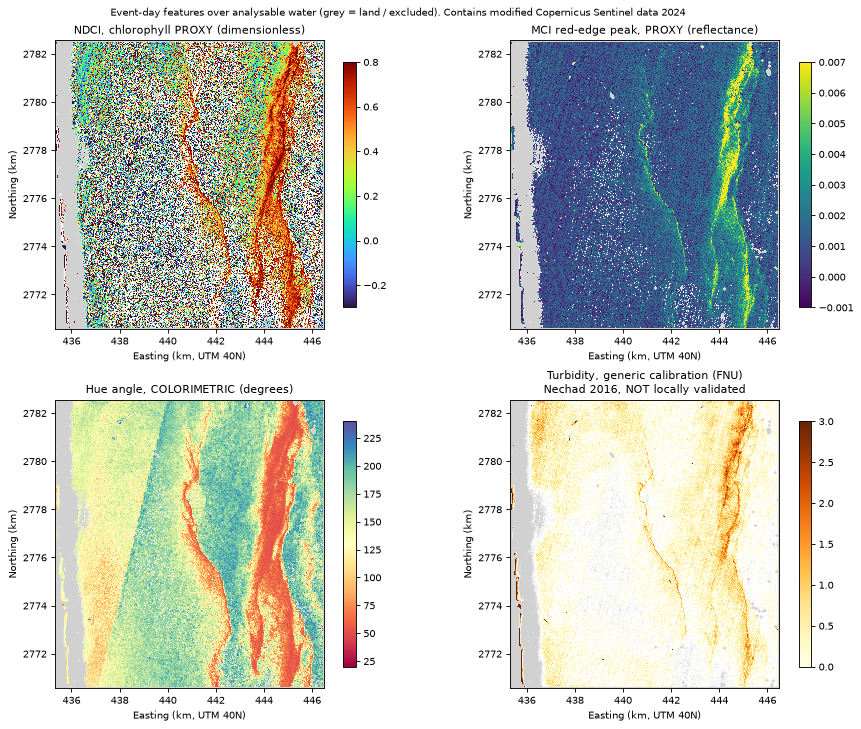

In [6]:
LABELS = {"NDCI": "NDCI, chlorophyll PROXY (dimensionless)",
          "MCI": "MCI red-edge peak, PROXY (reflectance)",
          "HUE_ANGLE": "Hue angle, COLORIMETRIC (degrees)",
          "TUR_NECHAD2016": "Turbidity, generic calibration (FNU)\nNechad 2016, NOT locally validated"}
STYLE = {"NDCI": dict(cmap="turbo", vmin=-0.3, vmax=0.8), "MCI": dict(cmap="viridis", vmin=-0.001, vmax=0.007),
         "HUE_ANGLE": dict(cmap="Spectral", vmin=20, vmax=240), "TUR_NECHAD2016": dict(cmap="YlOrBr", vmin=0, vmax=3)}
LAND_BG = np.where(valid & ~water, 0.82, np.where(valid, 1.0, 1.0))
fig, axs = plt.subplots(2, 2, figsize=(11.5, 9.0), constrained_layout=True)
for ax, k in zip(axs.ravel(), FEATS):
    ax.imshow(LAND_BG, extent=EXTENT, cmap="gray", vmin=0, vmax=1)
    im = ax.imshow(X[k], extent=EXTENT, interpolation="nearest", **STYLE[k])
    fig.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(LABELS[k])
    km_axes(ax)
fig.suptitle("Event-day features over analysable water (grey = land / excluded). "
             "Contains modified Copernicus Sentinel data 2024", fontsize=9)
fig.savefig(RESULTS / "02_features.png", bbox_inches="tight")
plt.show()

On one image, high NDCI and MCI alone do not make an event: NDCI blows up over very clear water and red-edge
indices also respond to bright shallow bottom. What matters is whether a value is unusual **for this pixel at
this time of year**.

## 4. DETECT: each pixel against its own same-season history

For the event date *t* and each feature *F*, the pipeline (`pipeline.detect.robust_anomaly`) uses the pixel's
values on acquisitions within ±45 days of the same day-of-year **in other years** (2024 itself excluded):

* robust z = (F_t − median) / (1.4826 · MAD + floor_F), the floor (0.02 for NDCI) stops a nearly constant history
  from producing huge z from sensor noise;
* seasonal percentile = 100 · #(history < F_t) / n, valid when n ≥ 6.

The sample input carries, for every pixel, the `n`, median and MAD of each feature over the same 36
same-season acquisitions (2018-2026) the incident builder used, plus two order statistics of NDCI for the
percentile tests: *pct ≥ 95* holds exactly when F_t exceeds the ⌈0.95 n⌉-th smallest past value (`q95`), and
*pct = 100* when it exceeds every past value (`max`). To keep the file small the statistics are rounded to fixed
binary steps (NDCI to 2⁻¹³ ≈ 0.00012, MCI to 2⁻²² reflectance); `data/sample_input/manifest.json` shows that the
event obtained from these files is pixel-for-pixel the full-precision one. One west-east row of the raw history
is stored in full, so we can run `detect.robust_anomaly` itself and compare.

In [7]:
BASE_TIF = SAMPLE / MANIFEST["baseline"]["file"]
with rasterio.open(BASE_TIF) as src:
    assert src.crs == CRS and src.transform == GT and (src.height, src.width) == (H, W), "grids differ"
    BL = {}
    for i, nm in enumerate(src.descriptions):
        a = src.read(i + 1).astype("float32")
        if src.nodata is not None and not np.isnan(src.nodata):
            a[a == src.nodata] = np.nan
        BL[nm] = a * np.float32(src.scales[i]) + np.float32(src.offsets[i])
acq = MANIFEST["baseline"]["acquisitions"]
print(f"Seasonal baseline: {len(acq)} acquisitions, {acq[0]['datetime'][:10]} .. {acq[-1]['datetime'][:10]}, "
      f"years {', '.join(MANIFEST['baseline']['years'])} (2024 excluded); layers: {', '.join(BL)}")


def robust_z(name, x):
    """Robust z with pipeline.detect.robust_anomaly's formula and floors, from the stored median and MAD."""
    scale = 1.4826 * BL[f"{name}_mad"] + detect.FLOORS[name]
    z = (x - BL[f"{name}_median"]) / scale
    return np.where((BL[f"{name}_n"] >= detect.MIN_CLIM_N) & np.isfinite(x), z, np.nan).astype("float32")


ZFEATS = [k for k in FEATS if f"{k}_mad" in BL]                 # turbidity: median and count only
Z = {k: robust_z(k, X[k]) for k in ZFEATS}
ok_n = BL["NDCI_n"] >= detect.MIN_CLIM_N
PCT_GE95 = ok_n & (X["NDCI"] > BL["NDCI_q95"])        # robust_anomaly's pct >= 95
PCT_100 = ok_n & (X["NDCI"] > BL["NDCI_max"])         # above every past same-season value

# Check against the pipeline function itself, on the stored full-history transect
T = np.load(SAMPLE / MANIFEST["baseline"]["transect_file"])
ROW = int(T["row"])
THR = {"NDCI": detect.Z_MIN, "MCI": 1.0, "HUE_ANGLE": None}
chk = []
for k in ZFEATS:
    z_t = detect.robust_anomaly(X[k][ROW], T[k], detect.FLOORS[k])[0]
    both = np.isfinite(z_t) & np.isfinite(Z[k][ROW])
    row = {"feature": k, "pixels on transect": int(both.sum()),
           "max |z difference|": float(np.max(np.abs(z_t - Z[k][ROW])[both]))}
    if THR[k] is not None:
        row[f"same z >= threshold decision"] = bool(np.array_equal(z_t[both] >= THR[k], Z[k][ROW][both] >= THR[k]))
    chk.append(row)
z_ndci_t, pct_ndci_t, n_ndci_t, med_ndci_t, _ = detect.robust_anomaly(X["NDCI"][ROW], T["NDCI"], detect.FLOORS["NDCI"])
fin = np.isfinite(pct_ndci_t)
flips = np.where(fin & ((pct_ndci_t >= detect.PCT_MIN) != PCT_GE95[ROW]))[0]
srt = np.sort(T["NDCI"], axis=0)                                  # exact q95 from the full history
q95_exact = np.take_along_axis(srt, np.clip(np.ceil(0.95 * n_ndci_t - 1e-9).astype(int) - 1, 0, None)[None], 0)[0]
gap = np.abs(X["NDCI"][ROW] - q95_exact)[flips]
print(f"Transect (window row {ROW}): pct >= 95 agrees with robust_anomaly on {int(fin.sum()) - len(flips)} of "
      f"{int(fin.sum())} pixels" + (f"; the {len(flips)} that differ lie within {gap.max():.1e} of the exact 95th-percentile "
      f"value (stored rounded to 2^-13 = {2 ** -13:.1e})" if len(flips) else ""))
pd.DataFrame(chk).set_index("feature")

Seasonal baseline: 36 acquisitions, 2018-01-14 .. 2026-02-11, years 2018, 2019, 2020, 2021, 2022, 2023, 2025, 2026 (2024 excluded); layers: NDCI_n, NDCI_median, NDCI_mad, NDCI_q95, NDCI_max, MCI_n, MCI_median, MCI_mad, HUE_ANGLE_n, HUE_ANGLE_median, HUE_ANGLE_mad, TUR_NECHAD2016_n, TUR_NECHAD2016_median
Transect (window row 234): pct >= 95 agrees with robust_anomaly on 341 of 341 pixels


,pixels on transect,max |z difference|,same z >= threshold decision
feature,,,
NDCI,341,0.0133,True
MCI,479,0.0001,True
HUE_ANGLE,479,0.0671,NaN


**The event polygon.** The rule is the incident builder's (`scripts/build_incidents.py`) with the thresholds in
`pipeline.detect`: analysable water with NDCI robust z ≥ 3 **and** NDCI seasonal percentile ≥ 95, with the
secondary bloom-like feature agreeing (MCI z ≥ 1); a one-pixel morphological opening; then the connected
pieces near the DETECT candidate (within 1.5 km of its 120 m centroid) plus every piece of at least 0.125 km²
(a quarter of DETECT's 0.5 km² minimum region, so a filament broken up at 20 m is kept).

In [8]:
from pyproj import Transformer
from affine import Affine

# The DETECT candidate this incident was built from (committed output of scripts/build_detect.py, 120 m grid)
det = json.loads(Path("outputs/detect/AE-FUJ.json").read_text(encoding="utf-8"))
watch_grid = json.loads(Path("outputs/watch/AE-FUJ.json").read_text(encoding="utf-8"))["grid"]
cands = [c for c in det["candidates"] if c["date"] == "2024-02-17" and c["hypothesis"] == "BLOOM_LIKE"]
cand = max(cands, key=lambda c: c["area_km2"] * (c["features"].get("robust_z_primary") or 0))
r120, c120 = cand["centroid_rc"]
cx, cy = Affine(*watch_grid["transform"]) * (c120 + 0.5, r120 + 0.5)
to_ll = Transformer.from_crs(f"EPSG:{EPSG}", "EPSG:4326", always_xy=True)
to_xy = Transformer.from_crs("EPSG:4326", f"EPSG:{EPSG}", always_xy=True)
lon0, lat0 = to_ll.transform(cx, cy)
print(f"DETECT candidate (120 m): {cand['area_km2']} km2, z {cand['features']['robust_z_primary']:.2f}, "
      f"centroid {lat0:.4f} N {lon0:.4f} E; {len(cands)} bloom-like candidates that day")

prim = detect.HYPOTHESIS_FEATURES["BLOOM_LIKE"][0][0]                    # NDCI
hit = water & (Z[prim] >= detect.Z_MIN) & PCT_GE95
for name, sign in detect.HYPOTHESIS_FEATURES["BLOOM_LIKE"][1:]:          # MCI must agree (z >= 1)
    hit &= (sign * np.nan_to_num(Z[name])) >= 1.0
hit = ndi.binary_opening(hit, iterations=1)
lab, nlab = ndi.label(hit)
ex_, ey_ = to_xy.transform(lon0, lat0)
cc0, rr0 = int((ex_ - GT.c) / GT.a), int((ey_ - GT.f) / GT.e)
sizes = ndi.sum(hit, lab, range(1, nlab + 1)) if nlab else []
rad = int(1500 / RES)
near = lab[max(0, rr0 - rad):rr0 + rad, max(0, cc0 - rad):cc0 + rad]
keep = set(np.unique(near[near > 0]).tolist())
min_px = max(1, int(detect.MIN_AREA_KM2 * 1e6 / 4 / RES ** 2))
keep |= {k for k in range(1, nlab + 1) if sizes[k - 1] >= min_px}
EVENT = np.isin(lab, sorted(keep))
N_PX = int(EVENT.sum())
AREA = N_PX * PX_KM2
assert AREA >= detect.MIN_AREA_KM2
rr, cc = np.where(EVENT)
ecx, ecy = GT * (cc.mean() + 0.5, rr.mean() + 0.5)
LON_C, LAT_C = to_ll.transform(ecx, ecy)


def emed(a, m=EVENT):
    v = a[m]
    v = v[np.isfinite(v)]
    return float(np.median(v)) if v.size else float("nan")


coast_water = ndi.binary_fill_holes(body | water)
dist_km = ndi.distance_transform_edt(coast_water) * RES / 1000
pct_class = np.where(PCT_100, 100.0, np.where(PCT_GE95, 95.0, 0.0))
S = {"n_px": N_PX, "area_km2": round(AREA, 3), "centroid_lonlat": [round(LON_C, 6), round(LAT_C, 6)],
     "n_components": len(keep), "ndci_z": emed(Z["NDCI"]), "share_above_all_past": float(PCT_100[EVENT].mean()),
     "share_ge95": float(PCT_GE95[EVENT].mean()), "ndci_pct_median": emed(pct_class),
     "n_seasonal_ndci": int(np.median(BL["NDCI_n"][EVENT])), "n_seasonal_hue": int(np.median(BL["HUE_ANGLE_n"][EVENT])),
     "ndci_value": emed(X["NDCI"]), "ndci_usual": emed(BL["NDCI_median"]),
     "mci_value": emed(X["MCI"]), "mci_usual": emed(BL["MCI_median"]), "mci_z": emed(Z["MCI"]),
     "hue_value": emed(X["HUE_ANGLE"]), "hue_usual": emed(BL["HUE_ANGLE_median"]), "hue_z": emed(Z["HUE_ANGLE"]),
     "tur_value": emed(X["TUR_NECHAD2016"]), "tur_usual": emed(BL["TUR_NECHAD2016_median"]),
     "dist_coast_km": emed(dist_km)}
print(f"Event: {S['n_px']:,} px = {S['area_km2']:.3f} km2 in {S['n_components']} connected pieces, centroid "
      f"{LAT_C:.4f} N {LON_C:.4f} E, median {S['dist_coast_km']:.1f} km from the nearest non-water pixel")
print(f"NDCI robust z (event median) {S['ndci_z']:.2f}; above every past same-season value on "
      f"{S['share_above_all_past']:.0%} of event pixels (median seasonal percentile {S['ndci_pct_median']:.0f}); "
      f"history per pixel: median {S['n_seasonal_ndci']} scenes (NDCI), {S['n_seasonal_hue']} (hue)")
print(f"MCI {S['mci_value']:.4f} vs usual {S['mci_usual']:.4f} (z {S['mci_z']:.1f}); "
      f"hue {S['hue_value']:.0f} deg vs usual {S['hue_usual']:.0f} deg (z {S['hue_z']:.1f}); "
      f"turbidity proxy {S['tur_value']:.2f} vs {S['tur_usual']:.2f} FNU (generic calibration)")

DETECT candidate (120 m): 1.944 km2, z 8.13, centroid 25.1123 N 56.4480 E; 5 bloom-like candidates that day


Event: 5,984 px = 2.394 km2 in 17 connected pieces, centroid 25.1157 N 56.4502 E, median 8.4 km from the nearest non-water pixel
NDCI robust z (event median) 7.32; above every past same-season value on 75% of event pixels (median seasonal percentile 100); history per pixel: median 31 scenes (NDCI), 33 (hue)
MCI 0.0068 vs usual 0.0007 (z 1.9); hue 54 deg vs usual 202 deg (z -5.8); turbidity proxy 1.27 vs 3.53 FNU (generic calibration)


**Compared with the committed incident.** `outputs/incidents/BB-AE-2024-001.json` was written by the full
pipeline (`scripts/build_incidents.py`, 30 Sep 2026) from the same acquisitions. The notebook recomputes the
same quantities from the sample input:

In [9]:
from shapely.geometry import shape

INC = json.loads(Path("outputs/incidents/BB-AE-2024-001.json").read_text(encoding="utf-8"))
wq = INC["water_quality"]["features"]
gtr = (GT.c, GT.a, 0.0, GT.f, 0.0, GT.e)
POLYS = export.mask_to_polygons(EVENT, gtr, EPSG, simplify_m=30.0, min_area_m2=4000.0)   # as the builder
mine = shapely.unary_union([shape(f["geometry"]) for f in POLYS["features"]])
theirs = shape(INC["geometry"])
iou = mine.intersection(theirs).area / mine.union(theirs).area

rows = [("Event area (km2, 20 m pixels)", INC["area_km2"], S["area_km2"]),
        ("NDCI robust z, event median", wq["NDCI"]["z"], S["ndci_z"]),
        ("NDCI seasonal percentile, event median", INC["temporal"]["seasonal_percentile"], S["ndci_pct_median"]),
        ("Same-season scenes per pixel (median; MCI/hue, NDCI)", INC["temporal"]["n_seasonal"],
         f"{S['n_seasonal_hue']} / {S['n_seasonal_ndci']}"),
        ("NDCI event / usual", f"{wq['NDCI']['value']:.3f} / {wq['NDCI']['baseline_median']:.4f}",
         f"{S['ndci_value']:.3f} / {S['ndci_usual']:.4f}"),
        ("MCI event / usual", f"{wq['MCI']['value']:.4f} / {wq['MCI']['baseline_median']:.4f}",
         f"{S['mci_value']:.4f} / {S['mci_usual']:.4f}"),
        ("Hue angle event / usual (deg)", f"{wq['HUE_ANGLE']['value']:.1f} / {wq['HUE_ANGLE']['baseline_median']:.1f}",
         f"{S['hue_value']:.1f} / {S['hue_usual']:.1f}"),
        ("Turbidity proxy event / usual (FNU)", f"{wq['TUR_NECHAD2016']['value']:.2f} / {wq['TUR_NECHAD2016']['baseline_median']:.2f}",
         f"{S['tur_value']:.2f} / {S['tur_usual']:.2f}"),
        ("Median distance to non-water (km; window-dependent)", INC["model_features"]["dist_shore_km"],
         S["dist_coast_km"]),
        ("Centroid (lon, lat)", INC["centroid"], S["centroid_lonlat"]),
        ("Polygon overlap with the committed geometry (IoU)", 1.0, round(iou, 4))]
CMP_INCIDENT = pd.DataFrame(rows, columns=["quantity", "committed incident JSON", "this notebook"]).set_index("quantity")
CMP_INCIDENT

,committed incident JSON,this notebook
quantity,,
"Event area (km2, 20 m pixels)",2.394,2.394
"NDCI robust z, event median",7.3225,7.3237
"NDCI seasonal percentile, event median",100.0,100.0
"Same-season scenes per pixel (median; MCI/hue, NDCI)",33,33 / 31
NDCI event / usual,0.678 / -0.0032,0.678 / -0.0032
MCI event / usual,0.0068 / 0.0007,0.0068 / 0.0007
Hue angle event / usual (deg),54.0 / 201.8,54.0 / 201.8
Turbidity proxy event / usual (FNU),1.27 / 3.53,1.27 / 3.53
Median distance to non-water (km; window-dependent),8.0682,8.3606


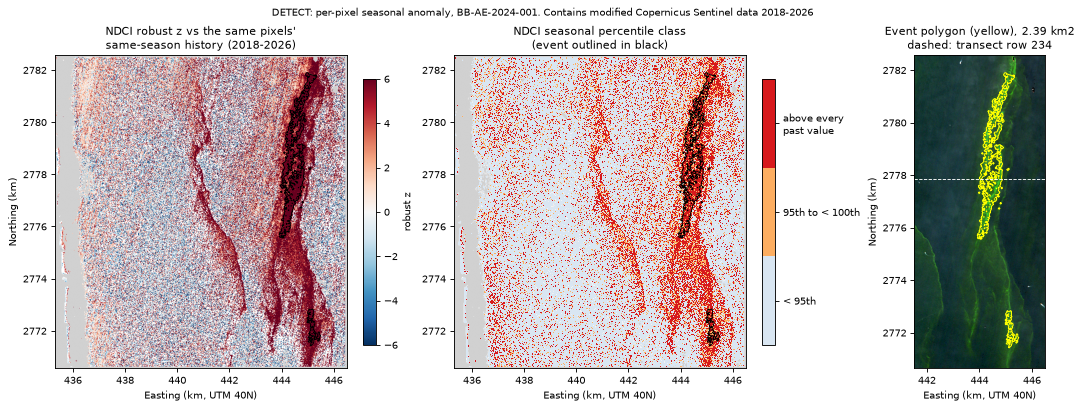

In [10]:
from matplotlib.colors import ListedColormap


def outline(ax, mask, color="k", lw=0.8):
    ax.contour(mask.astype(float), levels=[0.5], colors=color, linewidths=lw, extent=EXTENT, origin="upper")


fig, axs = plt.subplots(1, 3, figsize=(13.5, 5.0), constrained_layout=True, gridspec_kw={"width_ratios": [1, 1, 0.62]})
ax = axs[0]
ax.imshow(LAND_BG, extent=EXTENT, cmap="gray", vmin=0, vmax=1)
im = ax.imshow(Z["NDCI"], extent=EXTENT, cmap="RdBu_r", vmin=-6, vmax=6, interpolation="antialiased")
outline(ax, EVENT)
fig.colorbar(im, ax=ax, shrink=0.85, label="robust z")
ax.set_title("NDCI robust z vs the same pixels'\nsame-season history (2018-2026)")
km_axes(ax)
ax = axs[1]
ax.imshow(LAND_BG, extent=EXTENT, cmap="gray", vmin=0, vmax=1)
pc = np.where(water & ok_n, np.where(PCT_100, 2, np.where(PCT_GE95, 1, 0)), np.nan)
im = ax.imshow(pc, extent=EXTENT, cmap=ListedColormap(["#d9e6f2", "#fdae61", "#d7191c"]), vmin=-0.5, vmax=2.5,
               interpolation="nearest")
cb = fig.colorbar(im, ax=ax, shrink=0.85, ticks=[0, 1, 2])
cb.ax.set_yticklabels(["< 95th", "95th to < 100th", "above every\npast value"])
outline(ax, EVENT)
ax.set_title("NDCI seasonal percentile class\n(event outlined in black)")
km_axes(ax)
ax.set_ylabel("")
ax = axs[2]
r0_, r1_ = max(rr.min() - 40, 0), min(rr.max() + 40, H)
c0_, c1_ = max(cc.min() - 120, 0), min(cc.max() + 120, W)
sub_ext = [(GT.c + c0_ * RES) / 1000, (GT.c + c1_ * RES) / 1000, (GT.f - r1_ * RES) / 1000, (GT.f - r0_ * RES) / 1000]
ax.imshow(RGB[r0_:r1_, c0_:c1_], extent=sub_ext)
ax.contour(EVENT[r0_:r1_, c0_:c1_].astype(float), levels=[0.5], colors="yellow", linewidths=0.9,
           extent=sub_ext, origin="upper")
ax.axhline((GT.f - (ROW + 0.5) * RES) / 1000, color="w", ls="--", lw=0.8)
ax.set_title(f"Event polygon (yellow), {S['area_km2']:.2f} km2\ndashed: transect row {ROW}")
km_axes(ax)
fig.suptitle("DETECT: per-pixel seasonal anomaly, BB-AE-2024-001. Contains modified Copernicus Sentinel data 2018-2026",
             fontsize=9)
fig.savefig(RESULTS / "03_anomaly_polygon.png", bbox_inches="tight")
plt.show()

**What "against its own history" means, pixel by pixel.** Along the dashed row, every grey dot is one past
same-season value of one pixel, the black line is each pixel's usual (median) value and the red dots are the
event day. Over the event a whole run of neighbouring pixels sits far above its own history. Elsewhere the
event-day values scatter much like past values do: NDCI is noisy over very clear water, so isolated pixels
also pass z = 3 in the profile below (computed by `detect.robust_anomaly` from the full stored history of
this row). That is why the rule also asks for the 95th seasonal percentile, MCI agreement and a coherent
patch that survives the morphological opening.

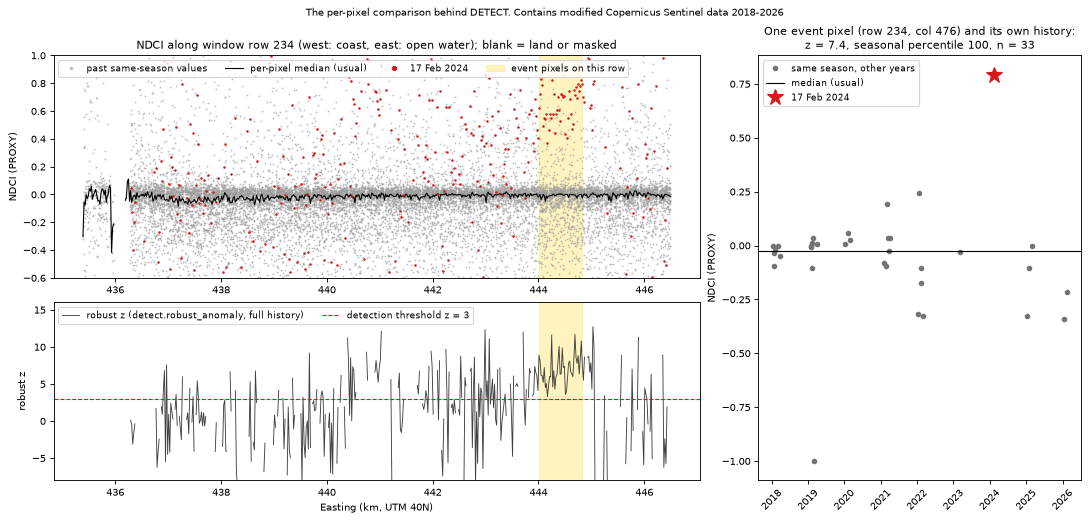

In [11]:
fig = plt.figure(figsize=(13.5, 6.4), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1])
xkm = (GT.c + (np.arange(W) + 0.5) * RES) / 1000
ev_cols = np.where(EVENT[ROW])[0]
ax = fig.add_subplot(gs[0, :2])
for i in range(T["NDCI"].shape[0]):
    ax.plot(xkm, T["NDCI"][i], ".", ms=1.3, color="0.62", alpha=0.6, label="past same-season values" if i == 0 else None)
ax.plot(xkm, med_ndci_t, "k-", lw=1, label="per-pixel median (usual)")
ax.plot(xkm, X["NDCI"][ROW], ".", color="#d7191c", ms=2.5, label="17 Feb 2024")
ax.axvspan(xkm[ev_cols.min()], xkm[ev_cols.max()], color="gold", alpha=0.25, label="event pixels on this row")
ax.set_ylim(-0.6, 1.0)
ax.set_ylabel("NDCI (PROXY)")
ax.legend(loc="upper left", fontsize=8, ncol=4, markerscale=3)
ax.set_title(f"NDCI along window row {ROW} (west: coast, east: open water); blank = land or masked")
ax = fig.add_subplot(gs[1, :2], sharex=fig.axes[0])
ax.plot(xkm, z_ndci_t, "-", color="0.25", lw=0.8, label="robust z (detect.robust_anomaly, full history)")
ax.axhline(detect.Z_MIN, color="#d7191c", ls="--", lw=1, label=f"detection threshold z = {detect.Z_MIN:.0f}")
ax.axvspan(xkm[ev_cols.min()], xkm[ev_cols.max()], color="gold", alpha=0.25)
ax.set_ylim(-8, 16)
ax.set_xlabel("Easting (km, UTM 40N)")
ax.set_ylabel("robust z")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax = fig.add_subplot(gs[:, 2])
cols = np.where(EVENT[ROW] & np.isfinite(z_ndci_t))[0]
cpx = int(cols[np.argsort(z_ndci_t[cols])[len(cols) // 2]])       # the event pixel with the median z on this row
dates = pd.to_datetime([str(d)[:10] for d in T["datetimes"]])
ax.plot(dates, T["NDCI"][:, cpx], "o", color="0.45", ms=4, label="same season, other years")
ax.axhline(med_ndci_t[cpx], color="k", lw=1, label="median (usual)")
ax.plot(pd.Timestamp("2024-02-17"), X["NDCI"][ROW, cpx], "*", color="#d7191c", ms=15, label="17 Feb 2024")
ax.set_title(f"One event pixel (row {ROW}, col {cpx}) and its own history:\n"
             f"z = {z_ndci_t[cpx]:.1f}, seasonal percentile {pct_ndci_t[cpx]:.0f}, n = {n_ndci_t[cpx]}")
ax.set_ylabel("NDCI (PROXY)")
ax.legend(fontsize=8, loc="upper left")
ax.tick_params(axis="x", rotation=45)
fig.suptitle("The per-pixel comparison behind DETECT. Contains modified Copernicus Sentinel data 2018-2026", fontsize=9)
fig.savefig(RESULTS / "03b_pixel_history.png", bbox_inches="tight")
plt.show()

## 5. DIAGNOSE: what kind of anomaly is it?

Three independent lines of evidence, each with its limits:

* **Spectrum.** Median SWIR-corrected reflectance of the event vs background water (the analysable water at
  least 200 m from the event with NDCI z < 1), with the background 5-95 % envelope.
* **Colour.** The Forel-Ule compatible hue angle (`s2_features.hue_angle`, Van der Woerd & Wernand 2018):
  clear blue water is about 200-230°, green about 90-120°, brown 20-60°.
* **A second sensor the same morning.** Sentinel-3 OLCI's Case-2 neural-network chlorophyll (CHL_NN), 300 m,
  30 minutes before Sentinel-2. This needs the OLCI granule and is **loaded from the committed pipeline output**
  (`outputs/incidents/BB-AE-2024-001.json`, computed by `pipeline.sentinel3.crosscheck`), not recomputed here.

In [12]:
SPEC_BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B8A"]
SPEC_NM = [443, 492, 560, 665, 704, 740, 865]
bg = water & ~ndi.binary_dilation(EVENT, iterations=10) & (np.nan_to_num(Z[prim]) < 1.0)
spec_e, spec_b, p05, p95 = [], [], [], []
for b in SPEC_BANDS:
    v = refl[b] - refl["B12"]
    ve, vb = v[EVENT], v[bg]
    ve, vb = ve[np.isfinite(ve)], vb[np.isfinite(vb)]
    spec_e.append(float(np.median(ve))); spec_b.append(float(np.median(vb)))
    p05.append(float(np.percentile(vb, 5))); p95.append(float(np.percentile(vb, 95)))
d_ev = np.nanmax(np.abs(np.array(spec_e) - np.array(INC["spectral"]["event"])))
d_bg = np.nanmax(np.abs(np.array(spec_b) - np.array(INC["spectral"]["background"])))
print(f"Event {N_PX:,} px vs background {int(bg.sum()):,} px. Largest difference from the committed spectra: "
      f"event {d_ev:.1e}, background {d_bg:.1e} (the committed background used the full 18 x 16 km window)")
print("Red-edge peak (B05 704 nm) event {:.4f} vs background {:.4f}; red B04 {:.4f} vs {:.4f}".format(
    spec_e[4], spec_b[4], spec_e[3], spec_b[3]))

OLCI = INC["sensor_agreement"]["Sentinel-3 OLCI"]
olci_tbl = pd.DataFrame([
    ("Granule", OLCI["item_id"]), ("Time vs Sentinel-2", f"{OLCI['dt_minutes']:+.0f} min"),
    ("Variable", f"{OLCI['variable']} ({OLCI['units']}), {OLCI['product']}"),
    ("Event footprint median (n px)", f"{OLCI['region_median']:.2f} ({OLCI['n_region_px']})"),
    ("Surrounding water median (n px)", f"{OLCI['background_median']:.2f} ({OLCI['n_background_px']:,})"),
    ("Ratio", f"x{OLCI['ratio']:.2f}")], columns=["Sentinel-3 OLCI cross-check (LOADED, not recomputed)", ""]
).set_index("Sentinel-3 OLCI cross-check (LOADED, not recomputed)")
olci_tbl

Event 5,984 px vs background 168,385 px. Largest difference from the committed spectra: event 1.4e-05, background 7.8e-04 (the committed background used the full 18 x 16 km window)
Red-edge peak (B05 704 nm) event 0.0161 vs background 0.0003; red B04 0.0034 vs -0.0004


,
"Sentinel-3 OLCI cross-check (LOADED, not recomputed)",
Granule,S3B_OL_2_WFR_20240217T061813_20240217T062113_0...
Time vs Sentinel-2,-30 min
Variable,"CHL_NN (mg m^-3), ESA OLCI WFR L2 Case-2 neura..."
Event footprint median (n px),13.12 (34)
Surrounding water median (n px),"3.19 (42,086)"
Ratio,x4.11


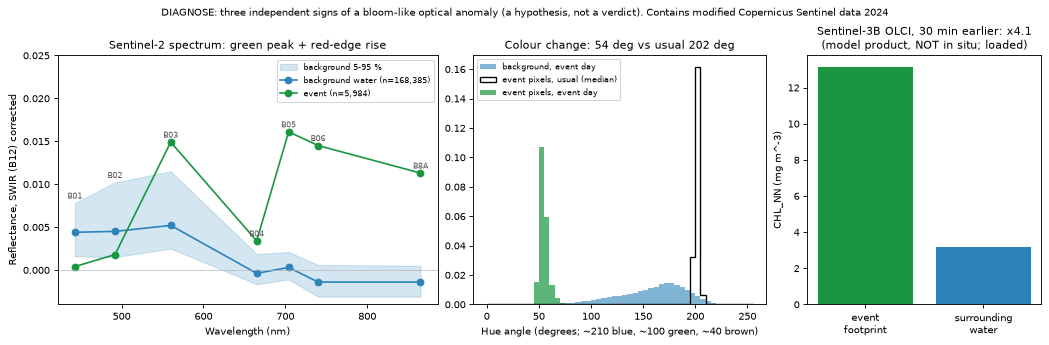

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True, gridspec_kw={"width_ratios": [1.3, 1, 0.8]})
a = ax[0]
a.fill_between(SPEC_NM, p05, p95, color="#2b83ba", alpha=0.2, label="background 5-95 %")
a.plot(SPEC_NM, spec_b, "o-", color="#2b83ba", label=f"background water (n={int(bg.sum()):,})")
a.plot(SPEC_NM, spec_e, "o-", color="#1a9641", label=f"event (n={N_PX:,})")
for nm, b in zip(SPEC_NM, SPEC_BANDS):
    a.annotate(b, (nm, max(spec_e[SPEC_NM.index(nm)], p95[SPEC_NM.index(nm)])), textcoords="offset points",
               xytext=(0, 4), ha="center", fontsize=7, color="0.35")
a.axhline(0, color="0.7", lw=0.6)
a.set_xlabel("Wavelength (nm)"); a.set_ylabel("Reflectance, SWIR (B12) corrected")
a.set_title("Sentinel-2 spectrum: green peak + red-edge rise")
a.set_ylim(-0.004, 0.025)
a.legend(fontsize=7.5, loc="upper right")
a = ax[1]
hb = X["HUE_ANGLE"][bg]; he = X["HUE_ANGLE"][EVENT]; hu = BL["HUE_ANGLE_median"][EVENT]
bins = np.arange(0, 260, 5)
a.hist(hb[np.isfinite(hb)], bins=bins, density=True, color="#2b83ba", alpha=0.6, label="background, event day")
a.hist(hu[np.isfinite(hu)], bins=bins, density=True, histtype="step", color="k", lw=1.2, label="event pixels, usual (median)")
a.hist(he[np.isfinite(he)], bins=bins, density=True, color="#1a9641", alpha=0.7, label="event pixels, event day")
a.set_xlabel("Hue angle (degrees; ~210 blue, ~100 green, ~40 brown)")
a.set_title(f"Colour change: {S['hue_value']:.0f} deg vs usual {S['hue_usual']:.0f} deg")
a.legend(fontsize=7)
a = ax[2]
a.bar(["event\nfootprint", "surrounding\nwater"], [OLCI["region_median"], OLCI["background_median"]],
      color=["#1a9641", "#2b83ba"])
a.set_ylabel(f"{OLCI['variable']} ({OLCI['units']})")
a.set_title(f"Sentinel-3B OLCI, {abs(OLCI['dt_minutes']):.0f} min earlier: x{OLCI['ratio']:.1f}\n"
            "(model product, NOT in situ; loaded)")
fig.suptitle("DIAGNOSE: three independent signs of a bloom-like optical anomaly (a hypothesis, not a verdict). "
             "Contains modified Copernicus Sentinel data 2024", fontsize=9)
fig.savefig(RESULTS / "04_spectra.png", bbox_inches="tight")
plt.show()

**Reading.** The event water is greener than its surroundings (a reflectance peak at 560 nm), with a trough at
665 nm (chlorophyll-a absorption) and a strong rise into the red edge at 704-740 nm: the classic signature of
high algal biomass near the surface. Its hue moved from blue (about 202°) to about 54°, the yellow-green to
brown end of the Forel-Ule scale, and a different satellite with a different algorithm saw about four times
the chlorophyll of the surrounding water 30 minutes earlier.
That is consistent with a **bloom-like optical anomaly** and it is *context-consistent* with the green
*Noctiluca* season in the Gulf of Oman (November-April). It does **not** identify a species, a toxin or a
concentration: that needs a water sample, which is what the VERIFY and ACT stages plan.

## 6. What would Satellite 813 add? (SIMULATED)

No Satellite 813 product is available to teams, so BLUEBAN 813 **simulates** the published 813 band set
(about 205 bands over 400-1700 nm, about 5 nm sampling; `pipeline.satellite813.spec_813`) from **real** Planet
Tanager-1 hyperspectral pixels: the open Tanager scene over the Gulf of Annaba (Algeria, 1 June 2025), where the
experiment was run; repeating it on a Tanager scene over the UAE is on the roadmap. The same pixels are convolved
to Sentinel-2's broad bands (`spec_sentinel2`) with Gaussian spectral response functions (`resample_spectra`), so
the only difference between the two arms is spectral configuration.

In [14]:
SP = json.loads(Path("outputs/events/BB-2026-001_spectra.json").read_text(encoding="utf-8"))
wl = np.asarray(SP["wavelengths_nm"], float)
tan = {"event": np.asarray(SP["event"]["mean"], float), "background": np.asarray(SP["background"]["mean"], float)}
S2SPEC, S813 = s813.spec_sentinel2(), s813.spec_813()
sim = {}
for name, spec in (("S2", S2SPEC), ("813", S813)):
    vals, _ = s813.resample_spectra(wl, np.stack([tan["event"], tan["background"]]), spec)
    sim[name] = {"nm": spec.centres_nm, "event": vals[0], "background": vals[1]}
n813 = int(np.isfinite(sim["813"]["event"]).sum())
ns2 = int(np.isfinite(sim["S2"]["event"]).sum())
print(f"Tanager-1 spectra: {len(wl)} bands, {wl.min():.0f}-{wl.max():.0f} nm (event n={SP['event']['n_pixels']:,} px, "
      f"background n={SP['background']['n_pixels']:,} px)")
print(f"Convolved: {ns2} Sentinel-2 bands and {n813} of {S813.n_bands} simulated 813 bands have spectral support in "
      f"{wl.min():.0f}-{wl.max():.0f} nm; the others (and Sentinel-2 B11/B12) come back as NaN, not extrapolated")

Tanager-1 spectra: 100 bands, 401-896 nm (event n=1,254 px, background n=186,578 px)
Convolved: 9 Sentinel-2 bands and 79 of 205 simulated 813 bands have spectral support in 401-896 nm; the others (and Sentinel-2 B11/B12) come back as NaN, not extrapolated


In [15]:
ABL = json.loads(Path("outputs/validation/detectability_lift_hard.json").read_text(encoding="utf-8"))
EASY = json.loads(Path("outputs/validation/detectability_lift_easy.json").read_text(encoding="utf-8"))
HYP = json.loads(Path("outputs/validation/hyperspectral_lift.json").read_text(encoding="utf-8"))
arms = {"S2_multispectral_11band": "Sentinel-2 (11 bands)", "813_hyperspectral_205band": "813 simulated (205 bands)",
        "813_hyperspectral_261band_5nm": "813 simulated (261 bands, 5 nm)"}
rows = []
for k, lbl in arms.items():
    r = ABL["results"]["spatial_blocked"][k]
    e = EASY["results"]["spatial_blocked"][k]
    rows.append({"band set": lbl, "false alarms (FP)": r["confusion_matrix"]["fp"], "missed (FN)": r["confusion_matrix"]["fn"],
                 "recall": r["recall"], "precision": r["precision"], "F1": r["f1"],
                 "FP, gross-plume regime": e["confusion_matrix"]["fp"]})
ABL_TBL = pd.DataFrame(rows).set_index("band set")
fp_s2 = ABL["results"]["spatial_blocked"]["S2_multispectral_11band"]["confusion_matrix"]["fp"]
fp_813 = ABL["results"]["spatial_blocked"]["813_hyperspectral_205band"]["confusion_matrix"]["fp"]
ABL_CUT = (fp_813 - fp_s2) / fp_s2
chl = HYP["targets"]["CHL_NN_log10"]["spatial_blocked"]
print(f"Operational decision boundary (every water pixel at the operating threshold, none dropped): "
      f"{ABL['n_samples']:,} pixels, {ABL['n_spatial_blocks']} spatial blocks of {ABL['block_size_m']} m, {ABL['n_folds']}-fold "
      f"spatially blocked CV.")
print(f"False alarms {fp_s2} -> {fp_813} ({ABL_CUT:+.0%}) at recall "
      f"{ABL['results']['spatial_blocked']['S2_multispectral_11band']['recall']:.3f} vs "
      f"{ABL['results']['spatial_blocked']['813_hyperspectral_205band']['recall']:.3f}; F1 gain 95% CI "
      f"[{ABL['hyperspectral_lift']['813_hyperspectral_205band']['f1_gain_ci95']['lo']:.4f}, "
      f"{ABL['hyperspectral_lift']['813_hyperspectral_205band']['f1_gain_ci95']['hi']:.4f}]")
print(f"Concentration vs OLCI CHL_NN ({HYP['n_matchups']} matchups, {abs(HYP['matchup_dt_hours']['median']):.1f} h apart): "
      f"R2 {chl['S2_multispectral_11band']['r2']:.2f} (S2) vs {chl['813_hyperspectral_205band']['r2']:.2f} (813): NOT demonstrated")
ABL_TBL

Operational decision boundary (every water pixel at the operating threshold, none dropped): 25,513 pixels, 173 spatial blocks of 1200 m, 5-fold spatially blocked CV.
False alarms 159 -> 84 (-47%) at recall 0.999 vs 0.999; F1 gain 95% CI [0.0050, 0.0080]
Concentration vs OLCI CHL_NN (658 matchups, 25.5 h apart): R2 0.08 (S2) vs 0.01 (813): NOT demonstrated


,false alarms (FP),missed (FN),recall,precision,F1,"FP, gross-plume regime"
band set,,,,,,
Sentinel-2 (11 bands),159,5,0.9991,0.9719,0.9853,0
813 simulated (205 bands),84,7,0.9987,0.9850,0.9918,0
"813 simulated (261 bands, 5 nm)",82,8,0.9985,0.9853,0.9919,0


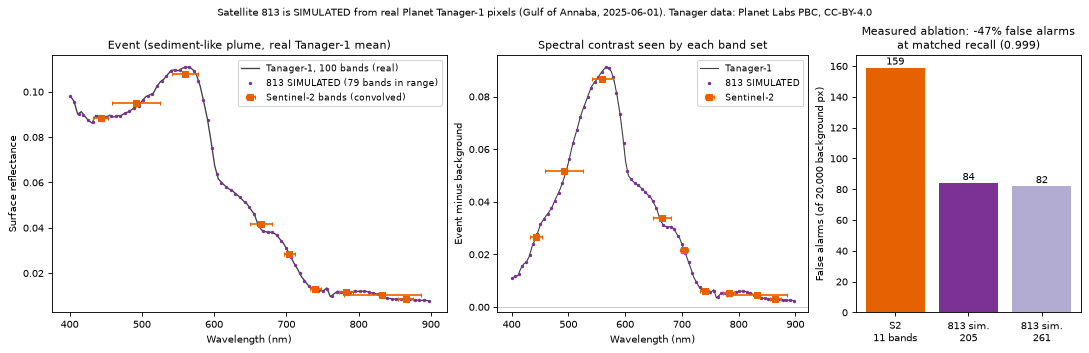

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.3), constrained_layout=True, gridspec_kw={"width_ratios": [1.4, 1.1, 0.8]})
for a, key, title in ((ax[0], "event", "Event (sediment-like plume, real Tanager-1 mean)"),):
    a.plot(wl, tan["event"], "-", color="0.25", lw=1.2, label=f"Tanager-1, {len(wl)} bands (real)")
    a.plot(sim["813"]["nm"], sim["813"]["event"], ".", color="#7b3294", ms=4, label=f"813 SIMULATED ({n813} bands in range)")
    m = np.isfinite(sim["S2"]["event"])
    a.errorbar(sim["S2"]["nm"][m], sim["S2"]["event"][m], xerr=S2SPEC.fwhm_nm[m] / 2, fmt="s", color="#e66101",
               ms=5, capsize=2, label="Sentinel-2 bands (convolved)")
    a.set_title(title)
a = ax[0]
a.set_xlabel("Wavelength (nm)"); a.set_ylabel("Surface reflectance")
a.legend(fontsize=8)
a = ax[1]
d813 = sim["813"]["event"] - sim["813"]["background"]
ds2 = sim["S2"]["event"] - sim["S2"]["background"]
a.plot(wl, tan["event"] - tan["background"], "-", color="0.25", lw=1, label="Tanager-1")
a.plot(sim["813"]["nm"], d813, ".", color="#7b3294", ms=4, label="813 SIMULATED")
m = np.isfinite(ds2)
a.errorbar(sim["S2"]["nm"][m], ds2[m], xerr=S2SPEC.fwhm_nm[m] / 2, fmt="s", color="#e66101", ms=5, capsize=2,
           label="Sentinel-2")
a.axhline(0, color="0.7", lw=0.6)
a.set_xlabel("Wavelength (nm)"); a.set_ylabel("Event minus background")
a.set_title("Spectral contrast seen by each band set")
a.legend(fontsize=8)
a = ax[2]
fps = [ABL["results"]["spatial_blocked"][k]["confusion_matrix"]["fp"] for k in arms]
bars = a.bar(["S2\n11 bands", "813 sim.\n205", "813 sim.\n261"], fps, color=["#e66101", "#7b3294", "#b2abd2"])
for b_, v in zip(bars, fps):
    a.text(b_.get_x() + b_.get_width() / 2, v + 2, str(v), ha="center", fontsize=9)
a.set_ylabel("False alarms (of 20,000 background px)")
a.set_title(f"Measured ablation: {ABL_CUT:+.0%} false alarms\nat matched recall (0.999)")
fig.suptitle("Satellite 813 is SIMULATED from real Planet Tanager-1 pixels (Gulf of Annaba, 2025-06-01). "
             "Tanager data: Planet Labs PBC, CC-BY-4.0", fontsize=9)
fig.savefig(RESULTS / "05_813_simulation.png", bbox_inches="tight")
plt.show()

**What 813 adds, measured, with its caveats.** At the operational decision boundary the simulated 813 band set
cut false alarms by about half at the same recall: the narrow bands resolve spectral shape that Sentinel-2's
broad bands average away. For a gross plume (the "easy" regime, borderline pixels excluded) both band sets
saturate and 813 adds nothing. A concentration benefit against OLCI chlorophyll was **not** demonstrated
(R² near zero for both arms, 658 matchups 25.5 h apart: underpowered). The reference labels are a full-spectrum
RX detector's judgement, not in-situ truth, and the 813 arm is simulated at Tanager's 30 m, not 813's 20 m.

## 7. LEARN: does a retrained model beat the production rule, and who decides?

Analyst decisions, field results and cross-sensor references become **labels**. The production triage model
`triage-1.0.0` is a transparent rule (`learning.rules_score`): a high seasonal percentile raises the score, a
persistent location or cloud adjacency lowers it. A retrained **candidate** is an L2, class-balanced logistic
regression on 13 triage features (`learning.fit_logistic`).

The seed label set holds 436 Sentinel-3 OLCI cross-sensor labels (weight 0.5: a reference, not ground truth),
split by AOI-month groups so that one event can never sit on both sides; 100 of them are a **frozen validation
set** identified by its hash. The candidate is compared with the rule on that set, with a grouped bootstrap of
the difference, per-AOI checks and leave-one-AOI-out testing, then the promotion gate runs
(`learning.evaluate_gate`, the same function the API trainer calls).

In [17]:
SEEDL = json.loads(Path("outputs/labels/seed_labels.json").read_text(encoding="utf-8"))
LABS = SEEDL["labels"]
F = learning.TRIAGE_FEATURES
tr = [l for l in LABS if l["split"] == "train"]
va = [l for l in LABS if l["split"] == "validation"]
Xt, yt, wt, gt, st = learning.to_matrix(tr, F)
Xv, yv, wv, gv, sv = learning.to_matrix(va, F)
yt, yv = yt.astype(int), yv.astype(int)
current_hash = learning.dataset_hash(va)
print(f"{len(LABS)} labels ({', '.join(sorted({l['source'] for l in LABS}))}, weight {LABS[0]['weight']}); "
      f"train {len(tr)} ({yt.sum()} positive), frozen validation {len(va)} ({yv.sum()} positive)")
print(f"Validation hash: frozen {SEEDL['validation_hash_python']}, recomputed {current_hash}")

prod = learning.rules_score(Xv, F)                                   # production: triage-1.0.0
ART = learning.fit_logistic(Xt, yt, wt, F, C=1.0)                     # candidate, train split only
cand = ART.predict(Xv)
m_prod, m_cand = learning.classification_metrics(yv, prod), learning.classification_metrics(yv, cand)
BOOT = learning.grouped_bootstrap_ci(yv, prod, cand, gv, learning._ap, n_boot=1000)   # seed 813 inside

loao = []
for a_ in sorted({l["aoi_id"] for l in LABS}):
    te = [l for l in LABS if l["aoi_id"] == a_]
    trn = [l for l in LABS if l["aoi_id"] != a_]
    Xa, ya, wa, _, _ = learning.to_matrix(trn, F)
    Xb, yb, _, _, _ = learning.to_matrix(te, F)
    row = {"held-out AOI": a_, "labels": len(te), "positive": int(yb.sum())}
    if len(set(ya.tolist())) == 2 and len(set(yb.tolist())) == 2:
        art_a = learning.fit_logistic(Xa, ya.astype(int), wa, F, C=1.0)
        row["AUPRC candidate"] = learning._ap(yb, art_a.predict(Xb))
        row["AUPRC rule"] = learning._ap(yb, learning.rules_score(Xb, F))
    loao.append(row)
LOAO = pd.DataFrame(loao).set_index("held-out AOI")
scored = LOAO.dropna(subset=["AUPRC candidate"])
WINS = int((scored["AUPRC candidate"] > scored["AUPRC rule"]).sum())

MET = pd.DataFrame({"production rule (triage-1.0.0)": m_prod, "candidate (logistic L2)": m_cand}).loc[
    ["auprc", "auroc", "f1", "precision", "recall", "brier", "ece"]]
print(f"\nAUPRC candidate {m_cand['auprc']:.3f} vs rule {m_prod['auprc']:.3f}; difference {BOOT['diff']:+.3f}, "
      f"grouped bootstrap 95% CI [{BOOT['ci'][0]:.3f}, {BOOT['ci'][1]:.3f}] ({BOOT['n_boot']} resamples)")
print(f"Leave-one-AOI-out: candidate beats the rule on {WINS} of {len(scored)} held-out AOIs "
      f"({len(LOAO) - len(scored)} AOI skipped: only one class)")
MET

436 labels (cross_sensor_reference, weight 0.5); train 336 (248 positive), frozen validation 100 (75 positive)
Validation hash: frozen c30fc552449c0de0, recomputed c30fc552449c0de0



AUPRC candidate 0.936 vs rule 0.658; difference +0.278, grouped bootstrap 95% CI [0.039, 0.476] (987 resamples)
Leave-one-AOI-out: candidate beats the rule on 9 of 9 held-out AOIs (1 AOI skipped: only one class)


,production rule (triage-1.0.0),candidate (logistic L2)
auprc,0.6579,0.9359
auroc,0.3531,0.7925
f1,0.8571,0.7867
precision,0.75,0.7867
recall,1.0,0.7867
brier,0.2218,0.1556
ece,0.2316,0.1616


In [18]:
TESTS = learning.model_tests(ART, Xv)
GATE = learning.evaluate_gate("triage", cand, prod, yv, gv, sv,
                              frozen_validation_hash=SEEDL["validation_hash_python"],
                              current_validation_hash=current_hash, tests=TESTS,
                              cfg=learning.GateConfig(primary_metric="auprc"))
for c in GATE["checks"]:
    print(f"  [{'PASS' if c['passed'] else 'FAIL'}] {c['name']}")
print(f"\nAutomatic gate: {'PASSED' if GATE['passed'] else 'FAILED'}; human approval required: "
      f"{GATE['human_approval']['required']}, approved by: {GATE['human_approval']['approved_by']}")

# The real promotion code path, on a throw-away in-memory store: a system account cannot promote.
from services.api import trainer
from services.api.store import Store

store = Store(":memory:")
seed_models = json.loads(Path("outputs/workspace/seed.json").read_text(encoding="utf-8"))["models"]
for m in seed_models:
    store.add_model(m, metrics=m.get("metrics"), actor="seed")
cand_id = "triage-1.1.0"
store.add_model({"id": cand_id, "task": "triage", "version": "1.1.0", "model_type": "logistic_l2",
                 "validation_dataset_hash": current_hash, "feature_set": F, "params": ART.extra,
                 "artifact": ART.to_dict(), "status": "CANDIDATE", "parent_model": "triage-1.0.0",
                 "notes": "trained in notebooks/blueban813_poc.ipynb", "gate": GATE}, actor="trainer")
try:
    trainer.promote(store, cand_id, approved_by="system")
    raise RuntimeError("a system account was able to promote: this must never happen")
except PermissionError as e:
    print(f"trainer.promote(..., approved_by='system') refused: {e}")
DECISION = ("CANDIDATE passed the automatic gate - awaiting named human approval" if GATE["passed"]
            else "CANDIDATE rejected by the automatic gate - production unchanged")
print(f"Production model: {store.production_model('triage')['id']}; candidate status: {store.get_model(cand_id)['status']}; "
      f"audit chain intact: {store.verify_audit_chain()['ok']}")
print(f"\nDecision: {DECISION}. Nothing is promoted automatically.")

  [PASS] model_test_suite
  [PASS] validation_dataset_unchanged
  [PASS] validation_has_both_classes
  [PASS] primary_metric_not_worse
  [PASS] calibration_acceptable
  [PASS] no_subgroup_regression

Automatic gate: PASSED; human approval required: True, approved by: None
trainer.promote(..., approved_by='system') refused: promotion requires a named human approver
Production model: triage-1.0.0; candidate status: CANDIDATE; audit chain intact: True

Decision: CANDIDATE passed the automatic gate - awaiting named human approval. Nothing is promoted automatically.


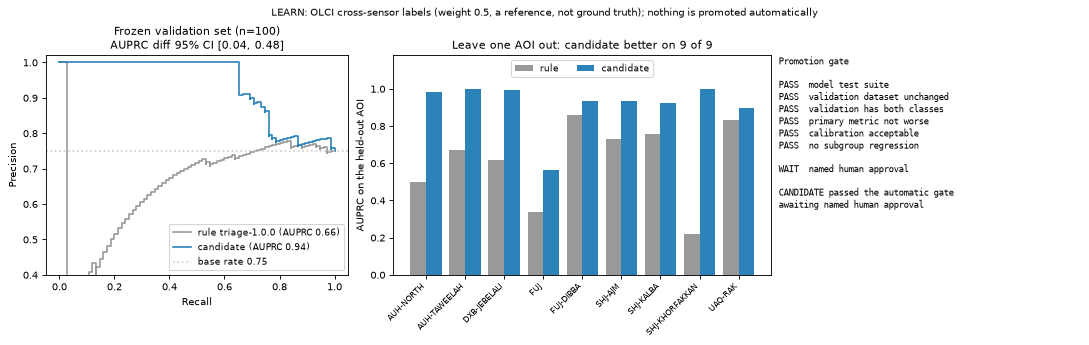

In [19]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True, gridspec_kw={"width_ratios": [1, 1.25, 1]})
a = ax[0]
for scores, lbl, col in ((prod, f"rule triage-1.0.0 (AUPRC {m_prod['auprc']:.2f})", "#999999"),
                         (cand, f"candidate (AUPRC {m_cand['auprc']:.2f})", "#2b83ba")):
    p_, r_, _ = precision_recall_curve(yv, scores)
    a.step(r_, p_, where="post", color=col, label=lbl)
a.axhline(yv.mean(), color="0.8", ls=":", label=f"base rate {yv.mean():.2f}")
a.set_xlabel("Recall"); a.set_ylabel("Precision"); a.set_ylim(0.4, 1.02)
a.set_title(f"Frozen validation set (n={len(yv)})\nAUPRC diff 95% CI [{BOOT['ci'][0]:.2f}, {BOOT['ci'][1]:.2f}]")
a.legend(fontsize=8, loc="lower right")
a = ax[1]
idx = np.arange(len(scored))
a.bar(idx - 0.2, scored["AUPRC rule"], 0.4, color="#999999", label="rule")
a.bar(idx + 0.2, scored["AUPRC candidate"], 0.4, color="#2b83ba", label="candidate")
a.set_xticks(idx)
a.set_xticklabels([s.replace("AE-", "") for s in scored.index], rotation=45, ha="right", fontsize=7)
a.set_ylabel("AUPRC on the held-out AOI")
a.set_title(f"Leave one AOI out: candidate better on {WINS} of {len(scored)}")
a.set_ylim(0, 1.18)
a.legend(fontsize=8, loc="upper center", ncol=2)
a = ax[2]
a.axis("off")
lines = [("PASS" if c["passed"] else "FAIL") + "  " + c["name"].replace("_", " ") for c in GATE["checks"]]
lines += ["", "WAIT  named human approval", "", DECISION.replace(" - ", "\n")]
a.text(0.0, 1.0, "Promotion gate\n\n" + "\n".join(lines), va="top", family="monospace", fontsize=8.5)
fig.suptitle("LEARN: OLCI cross-sensor labels (weight 0.5, a reference, not ground truth); nothing is promoted automatically",
             fontsize=9)
fig.savefig(RESULTS / "06_learning_gate.png", bbox_inches="tight")
plt.show()

The candidate is clearly better than the rule on this label set, but the evidence is modest: 100 validation
labels, all cross-sensor references, and a wide confidence interval. The gate therefore leaves production
untouched and records the candidate as **awaiting a named human's approval**; the API refuses a system account,
and a rollback restores the previous model in one step.

## 8. Results written to `results/`

One composite figure a judge can read at a glance, plus the event polygon (GeoJSON, EPSG:4326), the computed
numbers (JSON) and the comparison table (CSV). The step figures above were saved as `results/01_*.png` to
`results/06_*.png`.

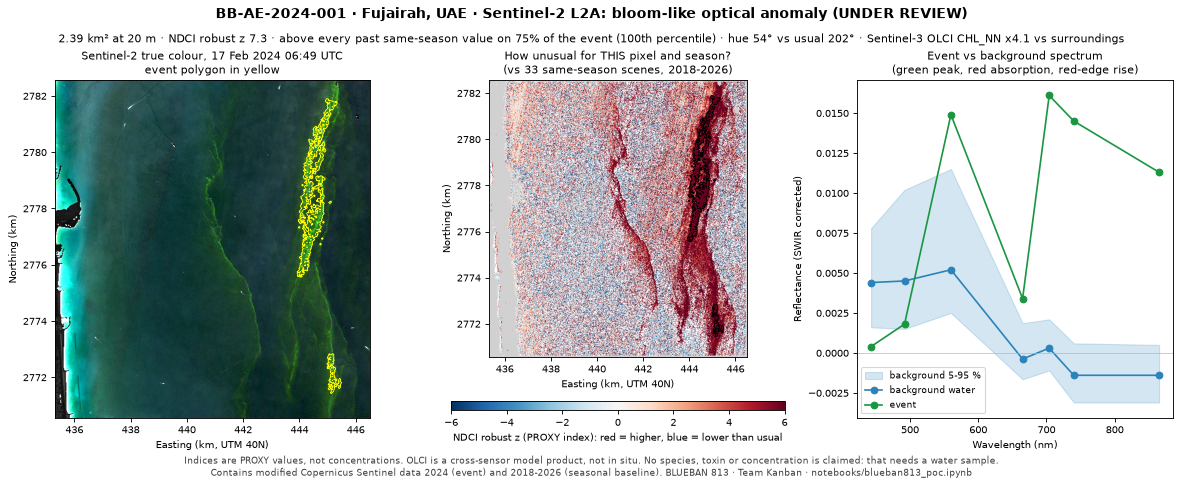

In [20]:
fig = plt.figure(figsize=(15, 6.3))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.95], left=0.045, right=0.985, top=0.83, bottom=0.16, wspace=0.22)
a = fig.add_subplot(gs[0])
a.imshow(RGB, extent=EXTENT)
outline(a, EVENT, color="yellow", lw=0.8)
a.set_title("Sentinel-2 true colour, 17 Feb 2024 06:49 UTC\nevent polygon in yellow")
km_axes(a)
a = fig.add_subplot(gs[1])
a.imshow(LAND_BG, extent=EXTENT, cmap="gray", vmin=0, vmax=1)
im = a.imshow(Z["NDCI"], extent=EXTENT, cmap="RdBu_r", vmin=-6, vmax=6, interpolation="antialiased")
outline(a, EVENT, color="k", lw=0.7)
cb = fig.colorbar(im, ax=a, orientation="horizontal", fraction=0.05, pad=0.13, aspect=35)
cb.set_label("NDCI robust z (PROXY index): red = higher, blue = lower than usual")
a.set_title(f"How unusual for THIS pixel and season?\n(vs {S['n_seasonal_hue']} same-season scenes, 2018-2026)")
km_axes(a)
a = fig.add_subplot(gs[2])
a.fill_between(SPEC_NM, p05, p95, color="#2b83ba", alpha=0.2, label="background 5-95 %")
a.plot(SPEC_NM, spec_b, "o-", color="#2b83ba", label="background water")
a.plot(SPEC_NM, spec_e, "o-", color="#1a9641", label="event")
a.axhline(0, color="0.7", lw=0.6)
a.set_xlabel("Wavelength (nm)"); a.set_ylabel("Reflectance (SWIR corrected)")
a.set_title("Event vs background spectrum\n(green peak, red absorption, red-edge rise)")
a.legend(fontsize=8)
fig.suptitle("BB-AE-2024-001 · Fujairah, UAE · Sentinel-2 L2A: bloom-like optical anomaly (UNDER REVIEW)",
             fontsize=13, fontweight="bold", y=0.975)
fig.text(0.5, 0.905, f"{S['area_km2']:.2f} km² at 20 m · NDCI robust z {S['ndci_z']:.1f} · above every past same-season "
         f"value on {S['share_above_all_past']:.0%} of the event (100th percentile) · hue {S['hue_value']:.0f}° vs usual "
         f"{S['hue_usual']:.0f}° · Sentinel-3 OLCI CHL_NN x{OLCI['ratio']:.1f} vs surroundings",
         ha="center", fontsize=9.5)
fig.text(0.5, 0.045, "Indices are PROXY values, not concentrations. OLCI is a cross-sensor model product, not in situ. "
         "No species, toxin or concentration is claimed: that needs a water sample.\n"
         "Contains modified Copernicus Sentinel data 2024 (event) and 2018-2026 (seasonal baseline). "
         "BLUEBAN 813 · Team Kanban · notebooks/blueban813_poc.ipynb",
         ha="center", fontsize=8.5, color="0.25")
fig.savefig(RESULTS / "example_output.png", dpi=125, bbox_inches="tight")
plt.show()

In [21]:
import csv

# Event polygon, EPSG:4326 (one feature per connected piece, as the incident builder writes it)
for f in POLYS["features"]:
    f["properties"].update({"incident_id": "BB-AE-2024-001", "observation_utc": TAGS["DATETIME_UTC"],
                            "hypothesis": "BLOOM_LIKE (bloom-like optical anomaly, not a confirmed bloom)",
                            "rule": "pipeline.detect thresholds at 20 m: NDCI robust z >= 3 and seasonal percentile >= 95, "
                                    "MCI z >= 1, 1-pixel opening; pieces >= 0.125 km2 or within 1.5 km of the DETECT "
                                    "candidate (DETECT minimum region 0.5 km2)",
                            "quantity_kind": "PROXY", "sensor": f"{PLATFORM} MSI L2A",
                            "attribution": "Contains modified Copernicus Sentinel data 2024, 2018-2026"})
POLYS["name"] = "BB-AE-2024-001 event polygon"
POLYS["crs_note"] = "EPSG:4326 (lon, lat)"
(RESULTS / "event_polygon.geojson").write_text(json.dumps(POLYS, indent=1), encoding="utf-8")

PUBLISHED = [
    ("Event area (km2, 20 m)", 2.39, round(S["area_km2"], 2), "README; incident JSON 2.394"),
    ("NDCI robust z, event median", 7.3, round(S["ndci_z"], 2), "README"),
    ("NDCI seasonal percentile, event median", 100, S["ndci_pct_median"], "README"),
    ("Same-season scenes per event pixel (median)", 33, S["n_seasonal_hue"],
     "README (MCI/hue count; NDCI count %d, its ratio is undefined over the clearest water on some dates)" % S["n_seasonal_ndci"]),
    ("MCI event / usual", "0.0068 / 0.0007", f"{S['mci_value']:.4f} / {S['mci_usual']:.4f}", "README"),
    ("Hue angle event / usual (deg)", "54 / 202", f"{S['hue_value']:.0f} / {S['hue_usual']:.0f}", "README"),
    ("Median distance from the coast (km)", 8, round(S["dist_coast_km"], 1),
     "README (8.07 on the incident's 18 x 16 km window; distance to the nearest non-water pixel)"),
    ("OLCI CHL_NN event / surroundings (mg m-3)", "13.1 / 3.2 (x4.1)",
     f"{OLCI['region_median']:.1f} / {OLCI['background_median']:.1f} (x{OLCI['ratio']:.1f})", "README; LOADED, not recomputed"),
    ("813 sim.: false alarms S2 -> 813 at matched recall", "159 -> 84 (-47 %)", f"{fp_s2} -> {fp_813} ({ABL_CUT:+.0%})",
     "README; LOADED ablation, percentage recomputed"),
    ("Candidate vs rule AUPRC (frozen validation)", "0.94 vs 0.66", f"{m_cand['auprc']:.2f} vs {m_prod['auprc']:.2f}", "docs/JUDGING_MATRIX.md (scripts/build_validation.py)"),
    ("AUPRC difference, grouped bootstrap 95% CI", "[0.04, 0.48]", f"[{BOOT['ci'][0]:.2f}, {BOOT['ci'][1]:.2f}]", "docs/JUDGING_MATRIX.md"),
    ("Held-out AOIs where the candidate wins", "9 of 9", f"{WINS} of {len(scored)}", "docs/JUDGING_MATRIX.md"),
    ("Gate decision", "awaiting named human approval", DECISION, "README: humans promote models"),
]
with open(RESULTS / "computed_vs_published.csv", "w", newline="", encoding="utf-8") as fh:
    w_ = csv.writer(fh)
    w_.writerow(["quantity", "published", "this notebook", "published in / note"])
    w_.writerows(PUBLISHED)


def clean(o):
    if isinstance(o, dict):
        return {k: clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (float, np.floating)):
        return None if not np.isfinite(o) else round(float(o), 6)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


SUMMARY = {
    "incident_id": "BB-AE-2024-001", "status": INC["status"], "hypothesis": "BLOOM_LIKE: bloom-like optical anomaly",
    "observation": {"utc": TAGS["DATETIME_UTC"], "platform": PLATFORM, "stac_item": TAGS["STAC_ITEMS"],
                    "processing_baseline": BASELINE, "boa_add_offset": s2f.boa_offset_for_baseline(BASELINE)},
    "grid": {"crs": f"EPSG:{EPSG}", "pixel_m": RES, "shape": [H, W]},
    "detect": {**S, "rule": {"z_min": detect.Z_MIN, "pct_min": detect.PCT_MIN, "secondary": "MCI z >= 1",
                             "min_piece_km2": detect.MIN_AREA_KM2 / 4, "detect_min_region_km2": detect.MIN_AREA_KM2,
                             "window_days": 45, "floors": detect.FLOORS},
               "baseline_acquisitions": len(acq), "transect_check": chk, "polygon_iou_vs_committed": iou},
    "diagnose": {"spectrum_nm": SPEC_NM, "event": spec_e, "background": spec_b, "background_p05": p05,
                 "background_p95": p95, "olci_crosscheck_loaded": OLCI},
    "satellite_813_simulated": {"tanager_bands": len(wl), "s2_bands_in_range": ns2, "s813_bands_in_range": n813,
                                "false_alarms_s2": fp_s2, "false_alarms_813_205": fp_813, "change": ABL_CUT,
                                "chl_nn_r2_s2": chl["S2_multispectral_11band"]["r2"],
                                "chl_nn_r2_813": chl["813_hyperspectral_205band"]["r2"], "source": "outputs/validation (loaded)"},
    "learn": {"n_labels": len(LABS), "n_train": len(tr), "n_validation": len(va), "validation_hash": current_hash,
              "production": m_prod, "candidate": m_cand, "auprc_diff_ci95": BOOT["ci"], "loao_wins": WINS,
              "loao_scored": len(scored), "gate_passed": GATE["passed"], "decision": DECISION,
              "gate_checks": [{"name": c["name"], "passed": c["passed"]} for c in GATE["checks"]]},
    "computed_vs_published": [dict(zip(["quantity", "published", "notebook", "note"], r)) for r in PUBLISHED],
    "attribution": "Contains modified Copernicus Sentinel data 2024 (event) and 2018-2026 (baseline); "
                   "Tanager data: Planet Labs PBC (CC-BY-4.0)",
    "software": {"python": platform.python_version(), "numpy": np.__version__, "scikit_learn": sklearn.__version__,
                 "rasterio": rasterio.__version__},
}
(RESULTS / "incident_summary.json").write_text(json.dumps(clean(SUMMARY), indent=1), encoding="utf-8")
for f in sorted(RESULTS.iterdir()):
    print(f"results/{f.name:32s}{f.stat().st_size / 1e3:8.1f} kB")

results/01_true_colour.png                 454.2 kB
results/02_features.png                   1484.4 kB
results/03_anomaly_polygon.png             942.8 kB
results/03b_pixel_history.png              213.2 kB
results/04_spectra.png                      94.1 kB
results/05_813_simulation.png               92.4 kB
results/06_learning_gate.png                80.1 kB
results/computed_vs_published.csv            1.3 kB
results/event_polygon.geojson               94.5 kB
results/example_output.png                1329.8 kB
results/incident_summary.json                7.4 kB


## 9. Results and limitations

The table compares each headline number of the README and docs with what this notebook recomputed from the
sample input (or, where marked, loaded from a committed pipeline output it cannot recompute offline).

In [22]:
pd.DataFrame(PUBLISHED, columns=["quantity", "published", "this notebook", "published in / note"]).set_index("quantity")

,published,this notebook,published in / note
quantity,,,
"Event area (km2, 20 m)",2.39,2.39,README; incident JSON 2.394
"NDCI robust z, event median",7.3,7.32,README
"NDCI seasonal percentile, event median",100,100.0,README
Same-season scenes per event pixel (median),33,33,"README (MCI/hue count; NDCI count 31, its rati..."
MCI event / usual,0.0068 / 0.0007,0.0068 / 0.0007,README
Hue angle event / usual (deg),54 / 202,54 / 202,README
Median distance from the coast (km),8,8.4,README (8.07 on the incident's 18 x 16 km wind...
OLCI CHL_NN event / surroundings (mg m-3),13.1 / 3.2 (x4.1),13.1 / 3.2 (x4.1),"README; LOADED, not recomputed"
813 sim.: false alarms S2 -> 813 at matched recall,159 -> 84 (-47 %),159 -> 84 (-47%),"README; LOADED ablation, percentage recomputed"


**What this notebook shows.** From an 8.7 MB offline sample, the pipeline's own functions reproduce the hero
incident pixel for pixel: a 2.4 km² filament of discoloured water about 8 km off Fujairah whose chlorophyll
proxy is above every same-season value since 2018 on three quarters of its pixels (median robust z 7.3), whose
colour moved from blue to the yellow-green end of the scale, and which a second satellite independently saw as
chlorophyll-rich the same morning. A
retrained triage model beats the production rule on a frozen validation set, and the governance stops it at a
human.

**Limitations (read before quoting a number).**

* **Proxies, not concentrations.** NDCI, MCI and the hue angle are indices; turbidity uses published North
  Sea coefficients that are *not locally validated*. There are no public UAE in-situ chlorophyll, turbidity or
  TSS samples, so no concentration is printed anywhere.
* **Sen2Cor is a land processor.** The SWIR (B12) offset removes first-order glint only; it does not turn L2A
  into a water-leaving reflectance product.
* **A finite archive.** Each pixel's history is about 30-36 clear same-season scenes (2018-2026). A percentile
  of 100 means "above every one of them", not a return period.
* **The OLCI cross-check is a model product** (Case-2 neural net at 300 m), used as a reference with weight 0.5;
  it is loaded here, not recomputed, because it needs the OLCI granule.
* **Satellite 813 is simulated** from Tanager-1 pixels outside the UAE, at 30 m not 20 m; the ablation's labels
  come from a full-spectrum detector, not from water samples. The measured gain is on false alarms at the
  decision boundary, not on gross plumes and not on concentration.
* **Learning evidence is modest**: 436 cross-sensor labels, 100 in validation, a wide bootstrap interval, one
  AOI skipped in leave-one-AOI-out because it has only one class.
* **Sample input vs full pipeline.** The sample stores per-pixel statistics of the climatology (rounded to fixed
  binary steps), not the 36 raw images, on a 12 × 11 km window of the incident's 18 × 16 km grid, with B02/B03
  rounded to whole DN. The event mask is identical to the full-precision computation
  (`data/sample_input/manifest.json`, `reference_check`); z values differ by at most a few hundredths, and
  window-dependent quantities (background spectrum, distance to the nearest non-water pixel) differ slightly
  from the committed incident, as shown in the tables above.

*Data: Contains modified Copernicus Sentinel data 2024 (event) and 2018-2026 (seasonal baseline), processed by
ESA, accessed via Microsoft Planetary Computer. Tanager STAC Data, www.planet.com/data/stac © 2025 Planet Labs
PBC (CC-BY-4.0).*

In [23]:
print(f"Notebook finished in {time.time() - T0:.0f} s.")

Notebook finished in 29 s.
